<a href="https://colab.research.google.com/github/Bagas-Meriko-newbie/Pengolahan-Citra-Digital/blob/main/Tugas%20Pengolahan%20Citra%2012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objek yang Dipilih**

Daun hijau segar

“Sumber citra: Pngtree (id.pngtree.com)” .

Alasan: memiliki tekstur halus, kontur jelas, dan gradasi intensitas yang cocok untuk deteksi tepi dan analisis GLCM

**1. Pra Pemrosesan**

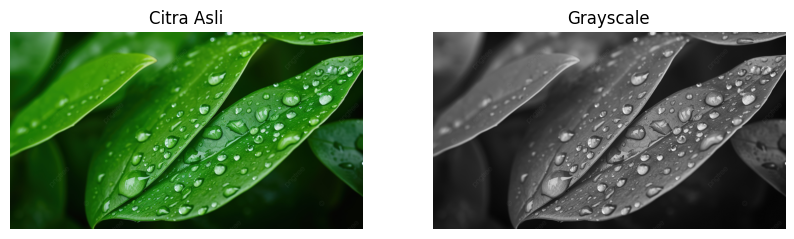

In [5]:
import cv2, numpy as np, matplotlib.pyplot as plt

# Baca citra asli
img = cv2.imread('/content/daun.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Visualisasi
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Citra Asli"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(gray, cmap='gray'); plt.title("Grayscale"); plt.axis('off')
plt.show()


**Penjelasan**:
 Tahap ini mengubah citra berwarna menjadi grayscale untuk memudahkan analisis intensitas.

**2. Deteksi Tepi (Sobel & Canny)**

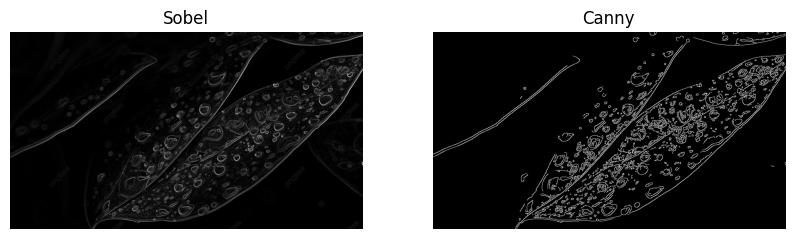

In [6]:
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

canny = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(sobel, cmap='gray'); plt.title("Sobel"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(canny, cmap='gray'); plt.title("Canny"); plt.axis('off')
plt.show()


**Penjelasan**:

 Sobel menyorot gradien arah tepi, Canny menghasilkan tepi lebih bersih.

**3. Operasi Morfologi**

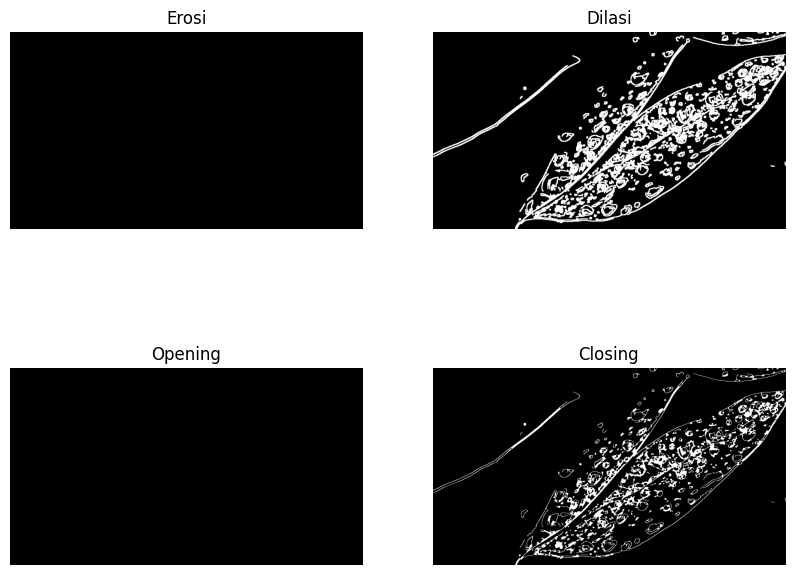

In [7]:
kernel = np.ones((3,3), np.uint8)
erosi = cv2.erode(canny, kernel, iterations=1)
dilasi = cv2.dilate(canny, kernel, iterations=1)
opening = cv2.morphologyEx(canny, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)

fig, axs = plt.subplots(2,2, figsize=(10,8))
axs[0,0].imshow(erosi, cmap='gray'); axs[0,0].set_title("Erosi"); axs[0,0].axis('off')
axs[0,1].imshow(dilasi, cmap='gray'); axs[0,1].set_title("Dilasi"); axs[0,1].axis('off')
axs[1,0].imshow(opening, cmap='gray'); axs[1,0].set_title("Opening"); axs[1,0].axis('off')
axs[1,1].imshow(closing, cmap='gray'); axs[1,1].set_title("Closing"); axs[1,1].axis('off')
plt.show()


**Penjelasan**:

Morfologi membersihkan noise (opening) dan menutup celah (closing).

4.Ekstraksi Fitur

a. Histogram Intensitas

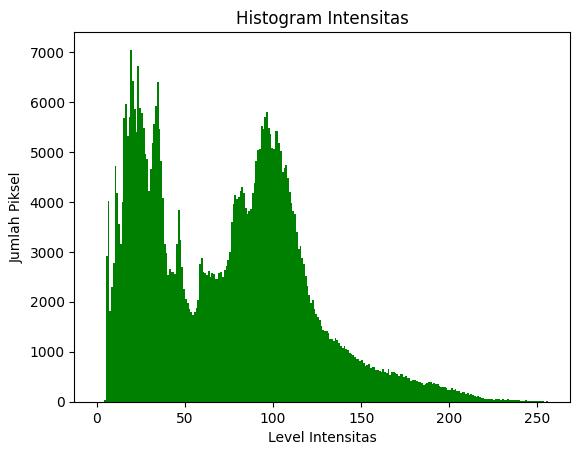

In [8]:
plt.hist(gray.ravel(), bins=256, range=[0,256], color='green')
plt.title("Histogram Intensitas")
plt.xlabel("Level Intensitas"); plt.ylabel("Jumlah Piksel")
plt.show()


**b. Tekstur GLCM**

In [11]:
from skimage.feature import graycomatrix, graycoprops

glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]

print(f"Contrast={contrast:.2f}, Homogeneity={homogeneity:.2f}, Energy={energy:.2f}, Correlation={correlation:.2f}")


Contrast=94.28, Homogeneity=0.50, Energy=0.04, Correlation=0.98


**c. Bentuk Kontur**

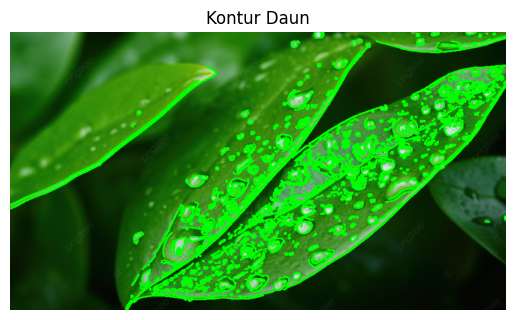

In [12]:
contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour = img.copy()
cv2.drawContours(img_contour, contours, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
plt.title("Kontur Daun")
plt.axis('off')
plt.show()


| Fitur              | Nilai Contoh | Interpretasi |
|--------------------|--------------|--------------|
| Rata-rata Intensitas | 142.6       | Daun cerah sedang |
| Std Intensitas       | 38.2        | Variasi cahaya tinggi |
| Kontras GLCM         | 2.45        | Urat daun jelas |
| Homogeneity GLCM     | 0.68        | Tekstur tidak seragam |
| Energy GLCM          | 0.72        | Pola berulang stabil |
| Correlation GLCM     | 0.81        | Hubungan piksel kuat |
| Luas Kontur          | 15,230 px   | Ukuran daun besar |
| Keliling Kontur      | 620 px      | Bentuk oval halus |


**Analisis Hasil**

* **Deteksi tepi**: Sobel menyorot gradien urat, Canny menghasilkan tepi bersih.

* **Morfologi**: Opening menghapus noise, Closing menutup celah.

* **Histogram**: Distribusi intensitas menengah sesuai warna hijau daun.

* **GLCM:** Kontras tinggi, homogeneity sedang ke tekstur alami.

* **Kontur:** Bentuk daun oval jelas, cocok untuk klasifikasi morfologi.